In [1]:
%reload_ext autoreload
%autoreload 2

In [30]:
from loguru import logger
import matplotlib.pyplot as plt
import mlflow
import numpy as np
from pathlib import Path

from envs.env import SIRSEnv
from rl.q_iteration import compute_social_optimum_policy

/opt/conda/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:197: UserWarning: Failure attempting to register store for scheme "azureml": No module named 'azureml.mlflow'
  _tracking_store_registry.register_entrypoints()
/opt/conda/lib/python3.11/site-packages/mlflow/store/artifact/artifact_repository_registry.py:116: UserWarning: Failure attempting to register artifact repository for scheme "azureml": No module named 'azureml.mlflow'
  _artifact_repository_registry.register_entrypoints()


# Define environment and algorithm parameters

In [21]:
alg_params = {
    "n_episodes": 1e7,
    "alpha_max": 0.5,
    "alpha_min": 1e-4,
    "alpha_decay": 1e-4,
    "epsilon": 0.1,
    "discount_factor": 0.99,
}

env_params = {
    "size": 3,
    "encounter_rate": 1.1,
    "recovery_rate": 0.6,
    "resusceptible_rate": 0.3,
    "vaccination_rate": 0.2,
    "cost_infection": 2,
    "cost_lockdown": 1,
}

#unif = 1 / (
#    env_params["size"]
#    * (
#        env_params["encounter_rate"]
#        + env_params["recovery_rate"]
#        + env_params["resusceptible_rate"]
#        + env_params["vaccination_rate"]
#    )
#)
#env_params["cost_infection"] *= unif
#env_params["cost_lockdown"] *= unif

## Compute Q-values via Value Iteration Algorithm

In [22]:
_, Q_true = compute_social_optimum_policy(
    size=env_params["size"],
    encounter_rate=env_params["encounter_rate"],
    recovery_rate=env_params["recovery_rate"],
    resusceptible_rate=env_params["resusceptible_rate"],
    vaccination_rate=env_params["vaccination_rate"],
    cost_infection=env_params["cost_infection"],
    cost_lockdown=env_params["cost_lockdown"],
    discount_factor=alg_params["discount_factor"],
    theta=1e-12,
    max_iterations=1e6,
)

2024-10-30 10:18:33.804 | INFO     | rl.q_iteration:compute_social_optimum_policy:75 - Social Optimum computation - Converged after 349 iterations, Delta: 9.663381206337363e-13


In [23]:
def Q_dict_to_array(Q: dict) -> np.array:
    indices = list(Q.keys())
    n_dims = len(indices[0])
    shape = []
    for dim in range(n_dims):
        shape.append(max([index[dim] for index in indices]) + 1)
    Q_arr = np.zeros(shape=shape)
    for k, v in Q_true.items():
        Q_arr[k] = v
    return Q_arr

In [24]:
def plot_values(Q: np.array):
    V = np.max(Q, axis=-1)
    mask = np.flip(np.tri(V.shape[0], V.shape[0], k=-1), 1)
    V_masked = np.ma.array(V, mask=mask)
    f, ax = plt.subplots()
    im = ax.imshow(V_masked.T)
    bar = plt.colorbar(im)
    ax.set_xticks(np.arange(V.shape[0]))
    ax.set_yticks(np.arange(V.shape[1]))
    ax.invert_yaxis()
    ax.set_xlabel("Susceptible")
    ax.set_ylabel("Infected")
    ax.set_title("Value function")
    return f, ax


def plot_policy(Q: np.array):
    policy = np.argmax(Q, axis=-1)
    f, ax = plt.subplots()
    for m_s in range(policy.shape[0]):
        for m_i in range(policy.shape[1] - m_s):  # same as policy.shape[0]
            if policy[m_s, m_i] == 0:
                ax.plot(m_s, m_i, "x", color="red", label="confinement")
            else:
                ax.plot(m_s, m_i, "o", color="green", label="max exposure")
    ax.set_xticks(np.arange(Q.shape[0]))
    ax.set_yticks(np.arange(Q.shape[1]))
    ax.set_title("Social Optimum Policy")
    ax.set_xlabel("Susceptible")
    ax.set_ylabel("Infected")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    # plt.plot()

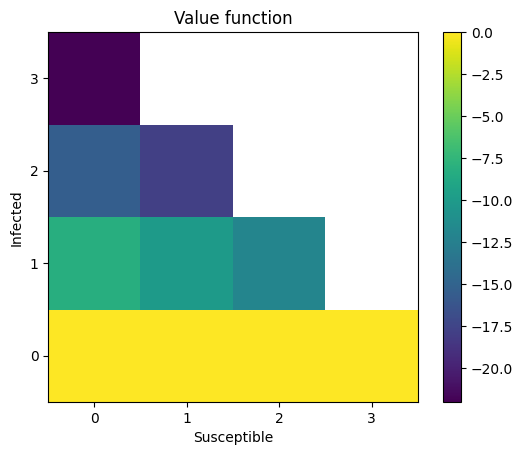

In [7]:
plot_values(Q_dict_to_array(Q_true));

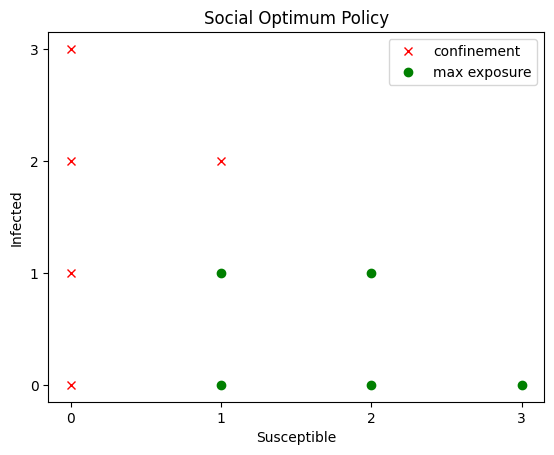

In [8]:
plot_policy(Q_dict_to_array(Q_true))

## Compute Q-values via Q-learning algorithm

In [25]:
env = SIRSEnv(
    **env_params,
)

In [32]:
def compute_error(Q_true: np.array, Q_approx: np.array):
    assert Q_true.shape == Q_approx.shape
    mask = np.flip(np.tri(Q_approx.shape[0], Q_approx.shape[0], k=-1), 1)
    Q_true_ = np.ma.array(Q_true, mask=mask)
    Q_approx_ = np.ma.array(Q_approx, mask=mask)
    return (
        np.ma.min(np.abs(Q_true_ - Q_approx_)),
        np.ma.mean(np.abs(Q_true_ - Q_approx_)),
        np.ma.median(np.abs(Q_true_ - Q_approx_)),
        np.ma.max(np.abs(Q_true_ - Q_approx_)),
    )

def compute_relative_error(Q_true: np. array, Q_approx: np.array):
    assert Q_true.shape == Q_approx.shape
    mask = np.flip(np.tri(Q_approx.shape[0], Q_approx.shape[0], k=-1), 1).astype(float)
    mask_zeros = (Q_true == 0).astype(float)  # TODO: Improve relative error metric when zeros, not remove
    mask = np.ma.mask_or(mask, mask_zeros)
    Q_true_ = np.ma.array(Q_true, mask=mask)
    Q_approx_ = np.ma.array(Q, mask=mask)
    return (
        np.ma.min(np.abs((Q_true_ - Q_approx_) / Q_true_)),
        np.ma.mean(np.abs((Q_true_ - Q_approx_) / Q_true_)),
        np.ma.median(np.abs((Q_true_ - Q_approx_) / Q_true_)),
        np.ma.max(np.abs((Q_true_ - Q_approx_) / Q_true_)),
    )

In [ ]:
experiment_name = "fixed-1"
outputs_dir = Path(f"outputs/{experiment_name}")
outputs_dir.mkdir(parents=True, exist_ok=True)

mlflow.set_experiment("SIRS RL")
with mlflow.start_run():
    mlflow.log_params(alg_params)
    mlflow.log_params(env_params)


    n_episodes = int(alg_params["n_episodes"])
    alpha_min = alg_params["alpha_min"]
    alpha_max = alg_params["alpha_max"]
    alpha_decay = alg_params["alpha_decay"]
    epsilon = alg_params["epsilon"]
    discount_factor = alg_params["discount_factor"]

    mlflow.set_tag("Algorithm type", "Fixed")

    Q = np.zeros(
        (env.observation_space[0].n, env.observation_space[1].n, env.action_space.n)
    )

    Q_true_arr = Q_dict_to_array(Q_true)
    for m_s in range(Q.shape[0]):
        for a in range(Q.shape[2]):
            Q[m_s, 0, a] = Q_true[(m_s, 0, a)]

    errors_max = []
    rel_errors_max = []
    for episode in range(n_episodes):
        logger.info(f"Episode {episode}")
        state, info = env.reset()
        alpha = alpha_min + (alpha_max - alpha_min) * np.exp(-alpha_decay * episode)
        logger.info(f"Learning rate: {alpha}")
        done = False
        steps = 0
        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = Q[state[0], state[1], :].argmax()
            next_state, reward, done, truncated, info = env.step(action)

            Q[state[0], state[1], action] = Q[state[0], state[1], action] + alpha * (
                reward
                + discount_factor * Q[next_state[0], next_state[1], :].max()
                - Q[state[0], state[1], action]
            )
            state = next_state
            steps += 1
            done = state[1] == 0
        
        errors = compute_error(np.max(Q_true_arr, axis=-1), np.max(Q, axis=-1))
        relative_errors = compute_relative_error(np.max(Q_true_arr, axis=-1), np.max(Q, axis=-1))
        metrics = {
            "error_min": errors[0],
            "error_mean": errors[1],
            "error_median": errors[2],
            "error_max": errors[3],
            "relative_error_min": relative_errors[0],
            "relative_error_mean": relative_errors[1],
            "relative_error_median": relative_errors[2],
            "relative_error_max": relative_errors[3],
            "lr": alpha
        }
        mlflow.log_metrics(metrics, step=episode)
        #rel_error_max = np.abs((Q_true_arr - Q) / Q_true_arr).max()
        #logger.info(f"Relative error max: {rel_error_max}")


2024-10-30 10:49:20.751 | INFO     | __main__:<module>:32 - Episode 0
2024-10-30 10:49:20.752 | INFO     | __main__:<module>:35 - Learning rate: 0.5


In [113]:
Q

array([[[  0.        ,   0.        ],
        [ -3.44873141,  -8.00110126],
        [-10.25802218, -10.86401772],
        [-20.4640294 , -13.23597964]],

       [[ -0.33333333,   0.        ],
        [ -9.54884637,  -5.12882829],
        [-14.58269563, -12.75391262],
        [  0.        ,   0.        ]],

       [[ -0.66666667,   0.        ],
        [-11.86507025,  -8.47247879],
        [  0.        ,   0.        ],
        [  0.        ,   0.        ]],

       [[ -1.        ,   0.        ],
        [  0.        ,   0.        ],
        [  0.        ,   0.        ],
        [  0.        ,   0.        ]]])

In [115]:
Q_true_arr[:, 0, :]

array([[ 0.        ,  0.        ],
       [-0.33333333,  0.        ],
       [-0.66666667,  0.        ],
       [-1.        ,  0.        ]])

In [116]:
Q[:, 0, :]

array([[ 0.        ,  0.        ],
       [-0.33333333,  0.        ],
       [-0.66666667,  0.        ],
       [-1.        ,  0.        ]])